In [2]:
import numpy as np
import matplotlib.pyplot as plt
# import radiomana #IDK how this works

train = np.loadtxt("../fiot_highway2-main/train.txt", dtype=str).tolist() #[ ['data/filenum', 'classification 1-9'], ... ]
test  = np.loadtxt("../fiot_highway2-main/test.txt",  dtype=str).tolist() #[ ['data/filenum', 'classification 1-9'], ... ]

# Split into paths and classes
train_file_paths = [row[0] for row in train]
train_classes    = [int(row[1]) for row in train]

n_chunks = 250
chunk_size = len(train_file_paths) // n_chunks

chunked_train_file_paths = np.array_split(train_file_paths, n_chunks)
chunked_train_class      = np.array_split(train_classes, n_chunks)

print(len(chunked_train_file_paths[0]))   
print(len(chunked_train_file_paths[-1]))   

53
52


In [3]:
# Load specific Chunk data
chunk_idx = 1
chunk_train_data  = [np.load("../fiot_highway2-main/" + fp) for fp in chunked_train_file_paths[chunk_idx]]
chunk_train_class = chunked_train_class[chunk_idx]

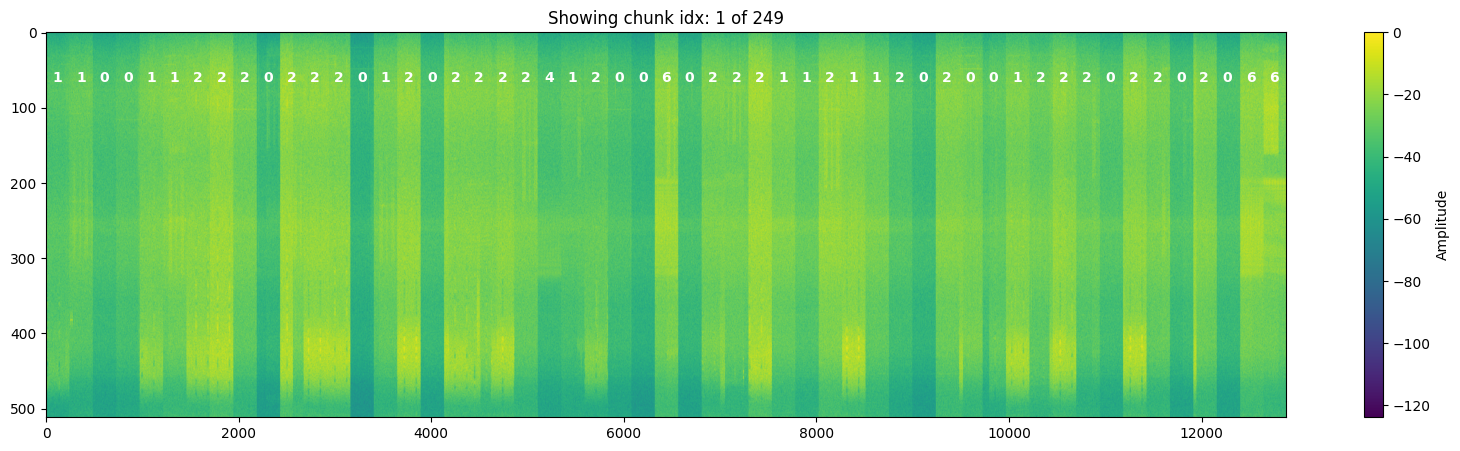

In [4]:
# Visualize Chunk data
plt.figure(figsize=(20, 5))

# Concatenate signals horizontally
img = np.hstack(chunk_train_data)
plt.imshow(img, aspect='auto', cmap='viridis')
plt.colorbar(label="Amplitude")

# Find y-position just above the image
y_pos = 0.10 * img.shape[0]   # 10% below the top row

# Overlay class labels
x_offset = 0
for data, cls in zip(chunk_train_data, chunk_train_class):
    mid_x = x_offset + data.shape[1] // 2
    plt.text(mid_x, y_pos, str(cls),
             ha='center', va='top',
             color='white', fontsize=10, fontweight='bold')
    x_offset += data.shape[1]

plt.title(f"Showing chunk idx: {chunk_idx} of {n_chunks-1}")
plt.show()

In [5]:
#what is the y axis????

#confirm that my labels on the above graph are correct.

In [6]:
# #each chunk has cells, each cell corresponds to a 000000 data file with a classification.

# #get a single number for each cell that represents the amount of amplitude

# #sum across the rows the amplitudes. then divide each row by its distance from the center + 1 / number of additions
# #then add all rows together and divide by number of additions
# # then for each cell plot its value vs x, 


# # Precompute center of rows
# n_rows = chunk_train_data[0].shape[0]
# center_row = n_rows // 2
# row_indices = np.arange(n_rows)
# weights = 1 / (np.abs(row_indices - center_row) + 1)

# # Compute single value per cell
# cell_values = []
# for cell in chunk_train_data:
#     # Sum across columns for each row
#     row_sums = np.sum(cell, axis=1)
    
#     # Apply weight
#     weighted_rows = row_sums * weights
    
#     # Average over rows
#     cell_value = np.sum(weighted_rows) / len(row_sums)
#     cell_values.append(cell_value)

# # Plot cell values vs index
# plt.figure(figsize=(12, 4))
# plt.plot(cell_values, 'o-')
# plt.xlabel("Cell index in chunk")
# plt.ylabel("Weighted amplitude")
# plt.title(f"Chunk {chunk_idx} cell amplitudes")
# plt.grid(True)
# plt.show()





In [7]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset
from torch.utils.data import DataLoader

In [8]:
class SizeAwareCNN(nn.Module):
    def __init__(self, num_classes, input_shape):
        super().__init__()
        self.conv1 = nn.Conv2d(1, 16, 3, padding=1)
        self.conv2 = nn.Conv2d(16, 32, 3, padding=1)
        self.pool = nn.MaxPool2d(2, 2)

        # Run a dummy tensor through to figure out flatten size
        with torch.no_grad():
            dummy = torch.zeros(1, 1, *input_shape)  # (B,C,H,W)
            out = self._forward_features(dummy)
            flat_size = out.view(1, -1).size(1)

        self.fc1 = nn.Linear(flat_size, 128)
        self.fc2 = nn.Linear(128, num_classes)

    def _forward_features(self, x):
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))
        return x

    def forward(self, x):
        x = self._forward_features(x)
        x = x.view(x.size(0), -1)
        x = F.relu(self.fc1(x))
        return self.fc2(x)

In [9]:
class MatrixDataset(Dataset):
    def __init__(self, matrices, labels):
        self.matrices = matrices  # list/array of 2D arrays
        self.labels = labels

    def __len__(self):
        return len(self.matrices)

    def __getitem__(self, idx):
        mat = torch.tensor(self.matrices[idx], dtype=torch.float32)
        mat = (mat - mat.mean()) / (mat.std() + 1e-6)  # normalize
        mat = mat.unsqueeze(0)  # add channel → [1, H, W]
        label = torch.tensor(self.labels[idx], dtype=torch.long)
        return mat, label

In [10]:
# # Example: 100 matrices with random varying sizes
# matrices = [np.random.rand(np.random.randint(20, 50), np.random.randint(20, 50)) for _ in range(100)]
# labels = np.random.randint(0, 5, size=100)  # 5 classes

# dataset = MatrixDataset(matrices, labels)
# loader = DataLoader(dataset, batch_size=8, shuffle=True, collate_fn=lambda x: x)

# model = FlexibleCNN(num_classes=5)
# criterion = nn.CrossEntropyLoss()
# optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

# # Training loop
# for epoch in range(3):
#     for batch in loader:
#         Xs, ys = zip(*batch)                     # list of tensors
#         Xs = torch.stack(Xs)                     # stack into batch
#         ys = torch.stack(ys)

#         outputs = model(Xs)
#         loss = criterion(outputs, ys)

#         optimizer.zero_grad()
#         loss.backward()
#         optimizer.step()

#     print(f"Epoch {epoch+1}, Loss: {loss.item():.4f}")

RuntimeError: stack expects each tensor to be equal size, but got [1, 40, 42] at entry 0 and [1, 42, 35] at entry 1

In [ ]:
#display 4 per graph